In [40]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)

from scipy.stats import norm
import pandas as pd

from utils import sample_batch, display

from vae_utils import get_vector_from_label, add_vector_to_images, morph_faces

In [2]:
IMAGE_SIZE = 512
CHANNELS = 1
BATCH_SIZE = 32
NUM_FEATURES = 20
Z_DIM = 64
LEARNING_RATE = 0.0005
EPOCHS = 100
BETA = 2000

In [3]:
# Load the data
train_data = utils.image_dataset_from_directory(
    r"C:\Users\E2021593.CEET\Desktop\Modified Mullers Images",
    labels=None,
    color_mode="grayscale",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)

Found 927 files.


In [4]:
# Preprocess the data
def preprocess(img):
    img = tf.cast(img, "float32") / 255.0
    return img


train = train_data.map(lambda x: preprocess(x))

In [5]:
train_sample = sample_batch(train)

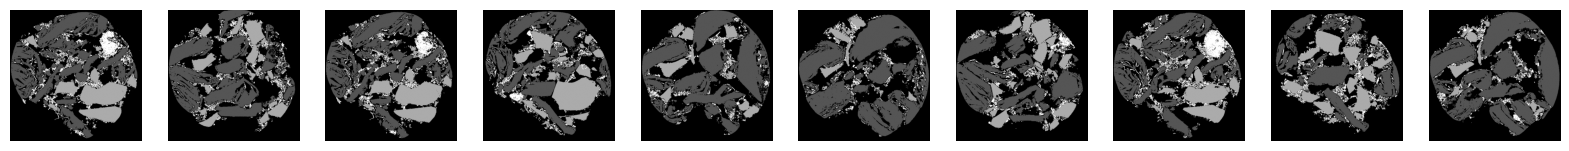

In [6]:
# Show some faces from the training set
display(train_sample, cmap='gray')

In [7]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
# Encoder
encoder_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_input"
)
#Block 1
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(
    encoder_input
)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
#Block 2
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(
    encoder_input
)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
#Block 3 
x = layers.Conv2D(NUM_FEATURES*2, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
#Block 4
x = layers.Conv2D(NUM_FEATURES*2, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
# Block 5
x = layers.Conv2D(NUM_FEATURES*4, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
# Block 6
x = layers.Conv2D(NUM_FEATURES*4, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 7
x = layers.Conv2D(NUM_FEATURES*8, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 8
x = layers.Conv2D(NUM_FEATURES*8, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Save the shape before flattening (required for the decoder)
shape_before_flattening = K.int_shape(x)[1:]  # the decoder will need this!

# Latent space
x = layers.Flatten()(x)
z_mean = layers.Dense(Z_DIM, name="z_mean")(x)
z_log_var = layers.Dense(Z_DIM, name="z_log_var")(x)

# Sampling layer
z = Sampling()([z_mean, z_log_var])

# Define the encoder model and model summary
encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, 512, 512, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 20)      │             200 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 256, 256, 20)      │              80 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 256, 256, 20)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 40)      │           7,240 │ leaky_re_lu_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 128, 128, 40)      │             160 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 128, 128, 40)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 40)        │          14,440 │ leaky_re_lu_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 64, 64, 40)        │             160 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 64, 64, 40)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 32, 32, 80)        │          28,880 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 32, 32, 80)        │             320 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)     │ (None, 32, 32, 80)        │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 16, 16, 80)        │          57,680 │ leaky_re_lu_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 16, 16, 80)        │             320 │ conv2d_5[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 784,488 (2.99 MB)

 Trainable params: 783,328 (2.99 MB)

 Non-trainable params: 1,160 (4.53 KB)

In [9]:
# Decoder
decoder_input = layers.Input(shape=(Z_DIM,), name="decoder_input")

# Block 1: Dense layer to reshape back to the feature map
x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Reshape(shape_before_flattening)(x)

# Block 2: Conv2DTranspose Layer 1
x = layers.Conv2DTranspose(
    NUM_FEATURES*8, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 3: Conv2DTranspose Layer 2
x = layers.Conv2DTranspose(
    NUM_FEATURES*8, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 4: Conv2DTranspose Layer 3
x = layers.Conv2DTranspose(
    NUM_FEATURES*4, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 5: Conv2DTranspose Layer 4
x = layers.Conv2DTranspose(
    NUM_FEATURES*4, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 6: Conv2DTranspose Layer 5
x = layers.Conv2DTranspose(
    NUM_FEATURES*2, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)


# Block 7: Conv2DTranspose Layer 6
x = layers.Conv2DTranspose(
    NUM_FEATURES*2, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 8: Conv2DTranspose Layer 7
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)


# Final Block: Output Layer
decoder_output = layers.Conv2DTranspose(
    CHANNELS, kernel_size=3, strides=1, activation="sigmoid", padding="same"
)(x)

# Define the decoder model and model summary
decoder = models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2560)                │         166,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 2560)                │          10,240 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 4, 4, 160)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 8, 8, 160)           │         230,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 8, 8, 160)           │             640 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 8, 8, 160)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 16, 16, 160)         │         230,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 160)         │             640 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 16, 16, 160)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 32, 32, 80)          │         115,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 32, 80)          │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 32, 32, 80)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 64, 64, 80)          │          57,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 64, 64, 80)          │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_12 (LeakyReLU)           │ (None, 64, 64, 80)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_4 (Conv2DTranspose) │ (None, 128, 128, 40)        │          28,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128, 128, 40)        │             1

 Total params: 863,721 (3.29 MB)

 Trainable params: 857,441 (3.27 MB)

 Non-trainable params: 6,280 (24.53 KB)

In [23]:
class VAE(models.Model):
   def __init__(self, encoder, decoder, **kwargs):
       super(VAE, self).__init__(**kwargs)
       self.encoder = encoder
       self.decoder = decoder
       self.total_loss_tracker = metrics.Mean(name="total_loss")
       self.reconstruction_loss_tracker = metrics.Mean(name="reconstruction_loss")
       self.kl_loss_tracker = metrics.Mean(name="kl_loss")
       self.reconstruction_loss_percent_tracker = metrics.Mean(name="reconstruction_loss_percent")
       self.kl_loss_percent_tracker = metrics.Mean(name="kl_loss_percent")
       self.previous_reconstruction_loss = tf.Variable(0.0, dtype=tf.float32, trainable=False)
       self.previous_kl_loss = tf.Variable(0.0, dtype=tf.float32, trainable=False)
       self.is_first_batch = tf.Variable(True, trainable=False)

   @property
   def metrics(self):
       return [
           self.total_loss_tracker,
           self.reconstruction_loss_tracker,
           self.kl_loss_tracker,
           self.reconstruction_loss_percent_tracker,
           self.kl_loss_percent_tracker,
       ]

   def call(self, inputs):
       z_mean, z_log_var, z = self.encoder(inputs)
       reconstruction = self.decoder(z)
       return z_mean, z_log_var, reconstruction

   def mean_squared_error(self, y_true, y_pred):
       return tf.reduce_mean(tf.square(y_true - y_pred))
       
   @tf.function
   def train_step(self, data):
       with tf.GradientTape() as tape:
           z_mean, z_log_var, reconstruction = self(data, training=True)
           
           reconstruction_loss = tf.reduce_mean(
               BETA * self.mean_squared_error(data, reconstruction)
           )
           kl_loss = tf.reduce_mean(
               tf.reduce_sum(
                   -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                   axis=1,
               )
           )
           total_loss = reconstruction_loss + kl_loss

       grads = tape.gradient(total_loss, self.trainable_weights)
       self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

       reconstruction_loss_percent = tf.where(
           self.is_first_batch,
           0.0,
           ((reconstruction_loss - self.previous_reconstruction_loss) / 
            self.previous_reconstruction_loss * 100)
       )
       
       kl_loss_percent = tf.where(
           self.is_first_batch,
           0.0,
           ((kl_loss - self.previous_kl_loss) / 
            self.previous_kl_loss * 100)
       )

       self.previous_reconstruction_loss.assign(reconstruction_loss)
       self.previous_kl_loss.assign(kl_loss)
       self.is_first_batch.assign(False)

       self.total_loss_tracker.update_state(total_loss)
       self.reconstruction_loss_tracker.update_state(reconstruction_loss)
       self.kl_loss_tracker.update_state(kl_loss)
       self.reconstruction_loss_percent_tracker.update_state(reconstruction_loss_percent)
       self.kl_loss_percent_tracker.update_state(kl_loss_percent)

       return {
           "loss": self.total_loss_tracker.result(),
           "reconstruction_loss": self.reconstruction_loss_tracker.result(),
           "kl_loss": self.kl_loss_tracker.result(),
           "reconstruction_loss_percent": self.reconstruction_loss_percent_tracker.result(),
           "kl_loss_percent": self.kl_loss_percent_tracker.result(),
       }

In [24]:
# Create a variational autoencoder
vae = VAE(encoder, decoder)

In [25]:
# Compile the variational autoencoder
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
vae.compile(optimizer=optimizer)

In [26]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)

In [27]:
vae.fit(
    train,
    epochs=EPOCHS,
    callbacks=[
        model_checkpoint_callback,
    ],
)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - kl_loss: 1.2841 - kl_loss_percent: 70.2559 - loss: 111.8888 - reconstruction_loss: 110.6047 - reconstruction_loss_percent: -1.9937
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - kl_loss: 1.6718 - kl_loss_percent: 1.4249 - loss: 77.5059 - reconstruction_loss: 75.8342 - reconstruction_loss_percent: -0.7513
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - kl_loss: 1.6308 - kl_loss_percent: -0.4623 - loss: 70.4866 - reconstruction_loss: 68.8558 - reconstruction_loss_percent: 0.0721
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - kl_loss: 1.3984 - kl_loss_percent: 3.8293 - loss: 68.4158 - reconstruction_loss: 67.0174 - reconstruction_loss_percent: 0.0561
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - kl_loss: 1.5866 - kl_loss_percent: 1.4876 - loss: 66.2410 - reconstruction_loss: 64.6544 - reconstruction_loss_percent: -0.2691
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - kl_loss: 2.2225 - kl_loss_percent: -1.

In [29]:
# Select a subset of the test set
batches_to_predict = 1
example_images = np.array(
    list(train.take(batches_to_predict).get_single_element())
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Example real Structures


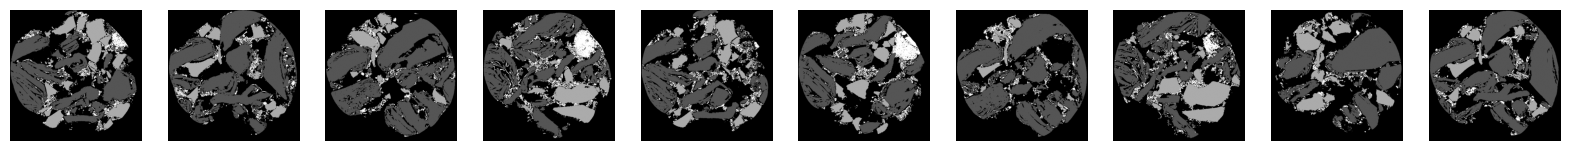

Reconstructions


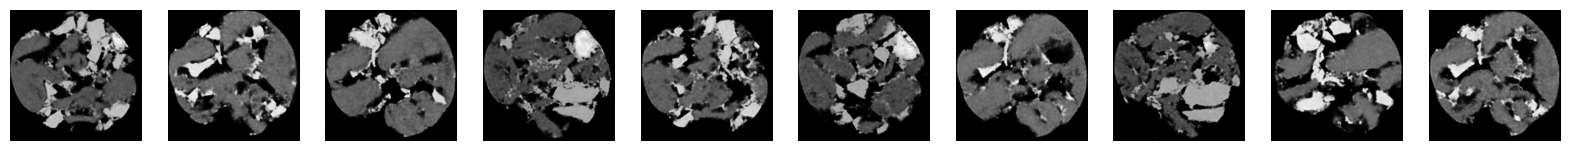

In [30]:
# Create autoencoder predictions and display
z_mean, z_log_var, reconstructions = vae.predict(example_images)
print("Example real Structures")
display(example_images)
print("Reconstructions")
display(reconstructions)


In [32]:
# Sample some points in the latent space, from the standard normal distribution
grid_width, grid_height = (10, 3)
z_sample = np.random.normal(size=(grid_width * grid_height, Z_DIM))

In [33]:
# Decode the sampled points
reconstructions = decoder.predict(z_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


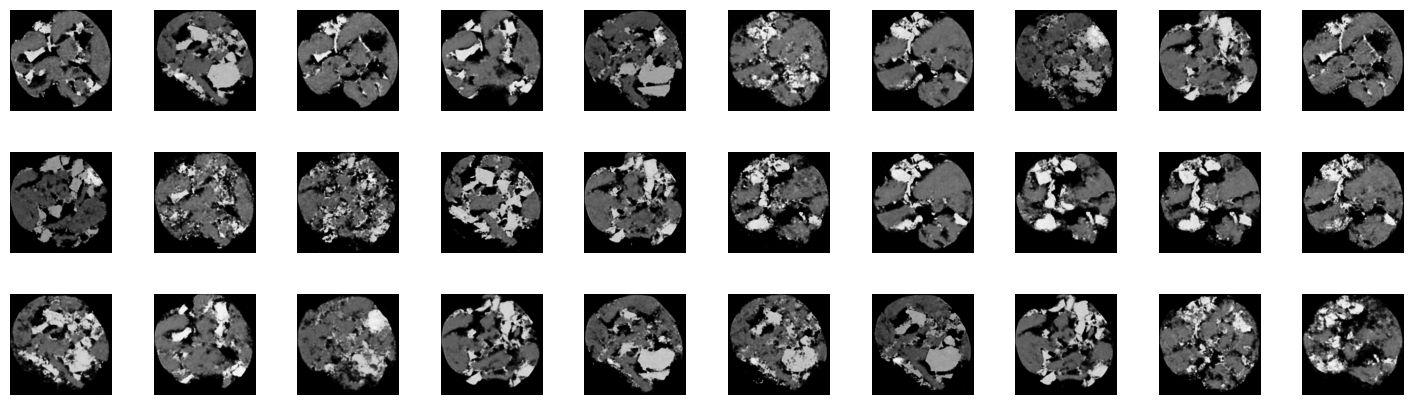

In [34]:
# Draw a plot of decoded images
fig = plt.figure(figsize=(18, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# Output the grid of faces
for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :],  cmap='gray')

In [35]:
import pandas as pd
# Load the label dataset
attributes = pd.read_csv(r"C:\Users\E2021593.CEET\Desktop\Mullers Code\area_pore_graphite_silicone_cbd.csv")
print(attributes.columns)
attributes.head()

Index(['Image Name', 'Pore Percentage', 'Graphite Percentage',
       'Silicone Percentage', 'CBD Percentage', 'Low Pore', 'Low-Medium Pore',
       'High-Medium Pore', 'High Pore', 'Low Graphite', 'Low-Medium Graphite',
       'High-Medium Graphite', 'High Graphite', 'Low Silicone',
       'Low-Medium Silicone', 'High-Medium Silicone', 'High Silicone',
       'Low CBD', 'Low-Medium CBD', 'High-Medium CBD', 'High CBD'],
      dtype='object')


,Image Name,Pore Percentage,Graphite Percentage,Silicone Percentage,CBD Percentage,Low Pore,Low-Medium Pore,High-Medium Pore,High Pore,Low Graphite,...,High-Medium Graphite,High Graphite,Low Silicone,Low-Medium Silicone,High-Medium Silicone,High Silicone,Low CBD,Low-Medium CBD,High-Medium CBD,High CBD
0,image_0000.png,65.99,19.39,7.74,6.88,-1,-1,1,-1,1,...,-1,-1,1,-1,-1,-1,1,-1,-1,-1
1,image_0001.png,66.20,19.55,7.84,6.42,-1,-1,1,-1,1,...,-1,-1,1,-1,-1,-1,1,-1,-1,-1
2,image_0002.png,66.45,19.60,7.93,6.02,-1,-1,1,-1,1,...,-1,-1,1,-1,-1,-1,1,-1,-1,-1
3,image_0003.png,66.70,19.59,8.01,5.70,-1,-1,1,-1,1,...,-1,-1,1,-1,-1,-1,1,-1,-1,-1
4,image_0004.png,66.93,19.51,8.08,5.48,-1,-1,1,-1,1,...,-1,-1,1,-1,-1,-1,1,-1,-1,-1


In [36]:
LABEL = "Low Graphite"  #Set this label
labelled_test = utils.image_dataset_from_directory(
   r"C:\Users\E2021593.CEET\Desktop\Modified Mullers Images",
    labels=attributes[LABEL].tolist(),
    color_mode="grayscale",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
)

labelled = labelled_test.map(lambda x, y: (preprocess(x), y))

Found 927 files belonging to 2 classes.
Using 185 files for validation.


In [37]:
# Find the attribute vector
attribute_vec = get_vector_from_label(labelled, vae, Z_DIM, LABEL)

label: Low Graphite
images : POS move : NEG move :distance : 𝛥 distance
25    : 1.823    : 3.124    : 3.872    : 3.872
48    : 1.13    : 2.03    : 2.893    : -0.979
68    : 0.65    : 1.194    : 2.276    : -0.617
89    : 0.52    : 0.685    : 2.06    : -0.216
109    : 0.397    : 0.61    : 2.05    : -0.01
127    : 0.225    : 0.465    : 1.937    : -0.113
149    : 0.24    : 0.38    : 1.859    : -0.077
169    : 0.243    : 0.317    : 1.791    : -0.068
191    : 0.231    : 0.283    : 1.809    : 0.018
209    : 0.156    : 0.269    : 1.874    : 0.065
229    : 0.172    : 0.198    : 1.83    : -0.045
247    : 0.13    : 0.22    : 1.793    : -0.037
269    : 0.139    : 0.183    : 1.785    : -0.008
288    : 0.118    : 0.194    : 1.743    : -0.041
311    : 0.134    : 0.152    : 1.708    : -0.035
333    : 0.134    : 0.157    : 1.654    : -0.054
351    : 0.091    : 0.171    : 1.648    : -0.006
371    : 0.09    : 0.151    : 1.64    : -0.008
391    : 0.092    : 0.148    : 1.6    : -0.039
412    : 0.082    : 0

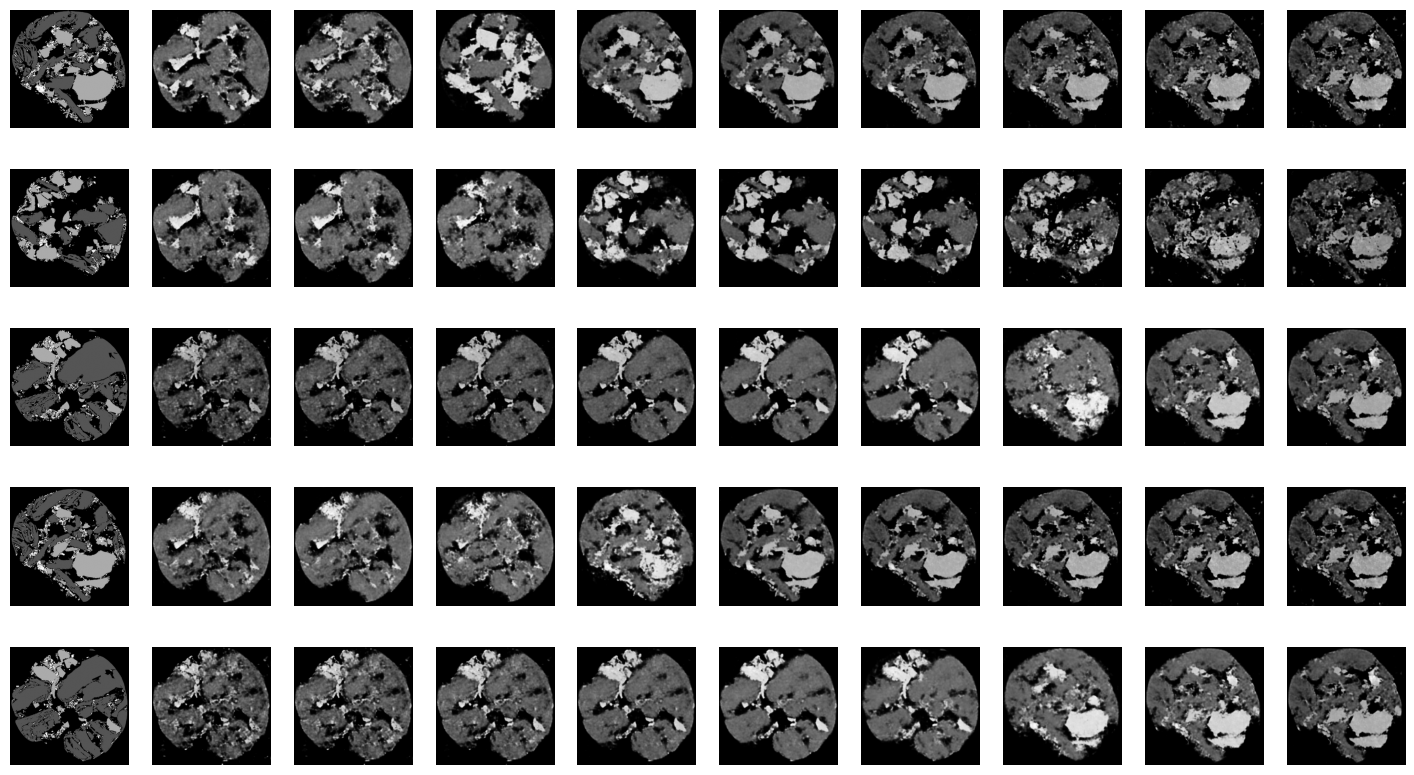

In [38]:
# Add vector to images
add_vector_to_images(labelled, vae, attribute_vec)

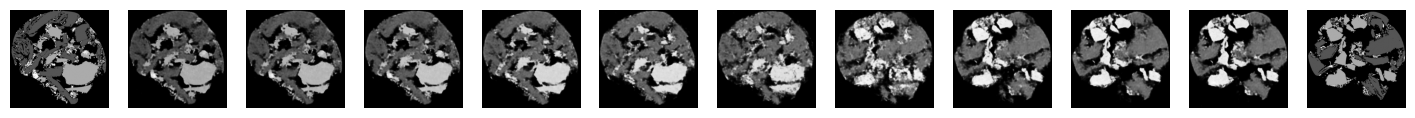

In [39]:
morph_faces(labelled, vae)

In [41]:
LABEL = "Low Graphite"  # Set this label
labelled_test = utils.image_dataset_from_directory(
   r"C:\Users\E2021593.CEET\Desktop\Modified Mullers Images",
    labels=attributes[LABEL].tolist(),
    color_mode="grayscale",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
)

labelled = labelled_test.map(lambda x, y: (preprocess(x), y))

Found 927 files belonging to 2 classes.
Using 185 files for validation.


In [42]:
# Find the attribute vector
attribute_vec = get_vector_from_label(labelled, vae, Z_DIM, LABEL)

label: Low Graphite
images : POS move : NEG move :distance : 𝛥 distance
25    : 1.835    : 3.15    : 4.059    : 4.059
48    : 1.148    : 2.002    : 3.153    : -0.906
68    : 0.611    : 1.395    : 2.36    : -0.793
89    : 0.525    : 0.811    : 2.173    : -0.187
109    : 0.326    : 0.671    : 2.107    : -0.066
127    : 0.233    : 0.491    : 2.094    : -0.014
149    : 0.255    : 0.357    : 2.074    : -0.019
169    : 0.237    : 0.36    : 2.038    : -0.036
191    : 0.167    : 0.249    : 2.039    : 0.001
209    : 0.194    : 0.303    : 2.025    : -0.014
229    : 0.162    : 0.238    : 2.004    : -0.021
247    : 0.15    : 0.229    : 1.958    : -0.045
269    : 0.149    : 0.198    : 1.926    : -0.033
288    : 0.119    : 0.218    : 1.858    : -0.067
311    : 0.144    : 0.147    : 1.812    : -0.046
333    : 0.124    : 0.157    : 1.728    : -0.084
351    : 0.114    : 0.142    : 1.709    : -0.019
371    : 0.096    : 0.15    : 1.696    : -0.012
391    : 0.089    : 0.134    : 1.666    : -0.03
412    : 

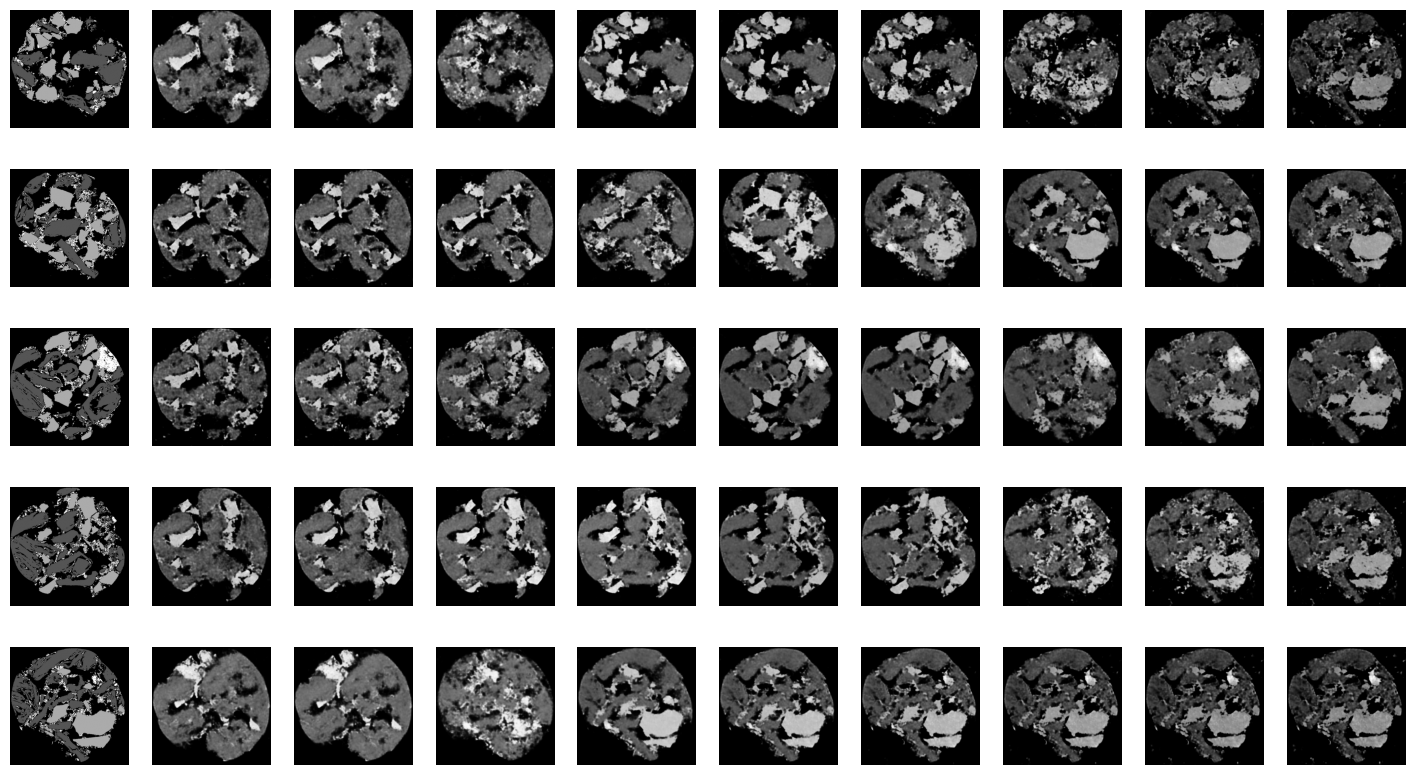

In [43]:
# Add vector to images
add_vector_to_images(labelled, vae, attribute_vec)

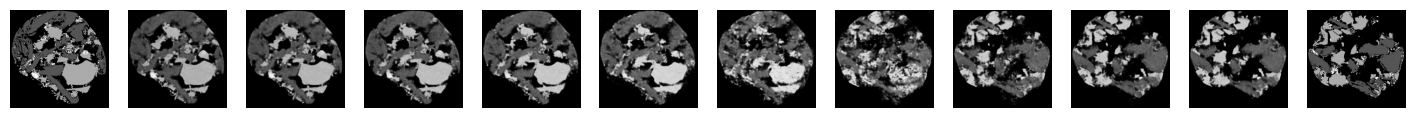

In [44]:
morph_faces(labelled, vae)